In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

In [2]:
import warnings
#предупреждение  печати statsmodels (verbose)
warnings.filterwarnings("ignore", category=FutureWarning, module="statsmodels")

In [3]:
df = pd.read_csv("climate_energy.csv")

Представлен временной ряд с экологическим, энерегетическими и экономическими факторами для Зимбабве - https://data.world/tadiwachawatama/energyclimatezimbabwe.

Столбцы:

__Временная метка__:
- `date` - дата в формате дд/мм/гггг. Записи производились раз в день в период с 1.1.2020 до 31.12.2024;

__Целевые переменные__:
- `co2_emission` - объем выбросов CO2 в сутки;
- `energy_consumption` - объем потребления энергии в сутки;

 __Экзогенные ряды__:
- `renewable_share` - доля возобновляемой энергии;
- `energy_price` - цена на электроэнергию.
- `avg_temperature` - среднесуточная температура;
- `humidity` - относительная влажность воздуха;
- `urban_population` - доля городского населения;
- `industrial_activity_index` - индекс промышленной активности;


**МЕТРИКИ**
*   MAE
*   SMAPE
* MASE
* RMSE

In [4]:
df.head()

,date,avg_temperature,humidity,co2_emission,energy_consumption,renewable_share,urban_population,industrial_activity_index,energy_price
0,1/1/2020,28.29,31.08,212.63,11348.75,14.42,76.39,51.22,83.93
1,2/1/2020,28.38,37.94,606.05,4166.64,5.63,86.26,78.27,110.40
2,3/1/2020,28.74,57.67,268.72,4503.80,14.20,75.92,48.96,173.58
3,4/1/2020,26.66,51.34,167.32,3259.13,13.84,63.15,97.42,89.13
4,5/1/2020,26.81,65.38,393.89,7023.72,6.93,76.02,81.89,40.60


# **Базовый анализ**

Проверим временной ряд на монотонность, дубликаты и пропуски

In [5]:
print(f'Монтонность: {df.index.is_monotonic_increasing}')
print(f'Дубликаты: {df.index.has_duplicates}')
print(f'Пропуски: {df.isna().sum().sum()}')

Монтонность: True
Дубликаты: False
Пропуски: 0


####  Задание временной индексации

- Преобразуем колонку `'date'` к типу временных меток `datetime` для корректной работы с временными рядами.
- Установим колонку `'time'` в качестве индекса DataFrame. Это позволит использовать удобные методы для работы с временными данными
- Установим **дневную частоту** (`'D'`)
- Выведем 5 случайных строк для оценки структуры данных

In [6]:
df['date'] = pd.to_datetime(df['date'], format='mixed', dayfirst=True)
df.set_index('date', inplace=True)
df = df.asfreq('d')
df['energy_consumption'] = df['energy_consumption'] / 1000

df.sample(5, random_state=0)

,avg_temperature,humidity,co2_emission,energy_consumption,renewable_share,urban_population,industrial_activity_index,energy_price
date,,,,,,,,
2020-10-25,14.92,63.34,166.68,4.72110,14.03,79.69,93.06,48.12
2021-05-04,26.75,61.43,625.55,10.76127,14.54,80.00,91.67,132.96
2020-10-05,14.25,77.61,715.52,4.96865,13.98,82.01,44.29,141.45
2022-03-06,33.56,40.74,922.44,7.49121,19.79,80.35,81.43,115.11
2022-06-11,22.49,80.94,340.64,4.70578,12.39,83.94,89.21,106.26


In [7]:
dt = df.index.to_series().diff().value_counts()
print(dt.head())

date
1 days    1826
Name: count, dtype: int64


Проверим, что можно обращаться к временному ряду по дате.

In [8]:
df.loc['2020-10'].head(5)

,avg_temperature,humidity,co2_emission,energy_consumption,renewable_share,urban_population,industrial_activity_index,energy_price
date,,,,,,,,
2020-10-01,13.29,42.23,827.50,3.11161,8.69,83.66,76.35,80.30
2020-10-02,10.67,43.50,353.18,7.40044,11.93,81.01,40.05,72.02
2020-10-03,10.67,84.47,129.74,5.93248,9.52,69.25,89.12,39.39
2020-10-04,10.13,72.08,231.62,6.91051,8.80,75.32,51.91,107.64
2020-10-05,14.25,77.61,715.52,4.96865,13.98,82.01,44.29,141.45


## Первичный анализ данных

### Описание датасета
Проведем анализ сформированного набора данных

__1. Общая информация о данных__

- **Форма данных**: `(количество строк, количество колонок)`
- **Индекс**: `имя индекса (тип данных)`
- **Диапазон дат**: `минимальная дата — максимальная дата`
- **Частота (если установлена)**: `H` (почасовая) или `None`

---

__2. Типы данных__

- **Распределение по типам**:  
  - `float64`: N колонок  
  - `int64`: M колонок  
  - и т.д.

---

__3. Базовая статистика__

- **Числовые колонки**: описательная статистика (среднее, std, min, max, квантили).

In [9]:
print(f"Описание: ")
print("-" * 50)
print(f"Форма данных: {df.shape}")
print(f"Индекс: {df.index.name} (тип: {df.index.dtype})")
print(f"Диапазон дат: {df.index.min()} — {df.index.max()}")
print(f"Частота: {df.index.freq}")
print("-" * 50)
print("\nТипы данных:")
print(df.dtypes.value_counts())
print("-" * 50)
print("-" * 50)
print("\nБазовая статистика (числовые колонки):")
df.describe()

Описание: 
--------------------------------------------------
Форма данных: (1827, 8)
Индекс: date (тип: datetime64[ns])
Диапазон дат: 2020-01-01 00:00:00 — 2024-12-31 00:00:00
Частота: <Day>
--------------------------------------------------

Типы данных:
float64    8
Name: count, dtype: int64
--------------------------------------------------
--------------------------------------------------

Базовая статистика (числовые колонки):


,avg_temperature,humidity,co2_emission,energy_consumption,renewable_share,urban_population,industrial_activity_index,energy_price
count,1827.000000,1827.000000,1827.000000,1827.000000,1827.000000,1827.000000,1827.000000,1827.000000
mean,22.439814,59.947635,449.447334,7.435521,15.963596,74.925435,70.009316,115.899962
std,8.210274,17.402773,233.825100,3.705869,5.347875,8.856308,17.428934,50.303655
min,7.680000,30.010000,59.290000,1.105660,5.030000,60.020000,40.010000,30.020000
25%,15.165000,45.110000,250.065000,4.301505,12.260000,67.160000,55.030000,71.060000
50%,22.490000,59.980000,424.770000,7.099380,15.570000,75.050000,69.860000,116.110000
75%,29.785000,75.370000,638.905000,10.335870,19.955000,82.655000,85.170000,161.220000
max,37.410000,89.960000,995.410000,15.998050,30.650000,89.980000,99.970000,199.950000


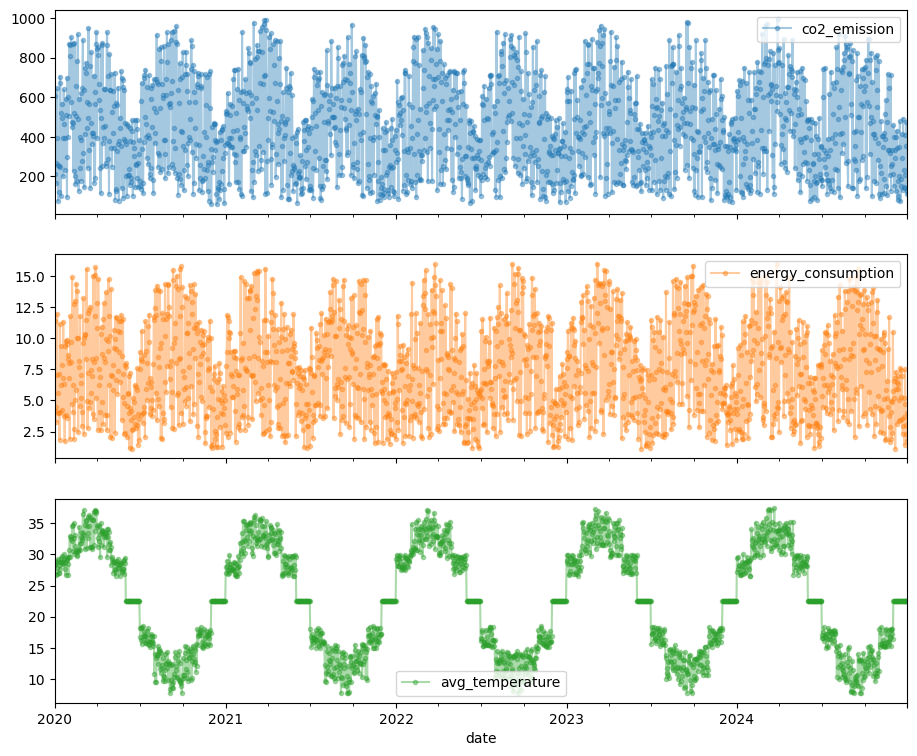

In [10]:
cols_plot = ['co2_emission', 'energy_consumption','avg_temperature']
axes = df[cols_plot].plot(marker='.', alpha=0.4, linestyle='-', figsize=(11, 9), subplots=True)

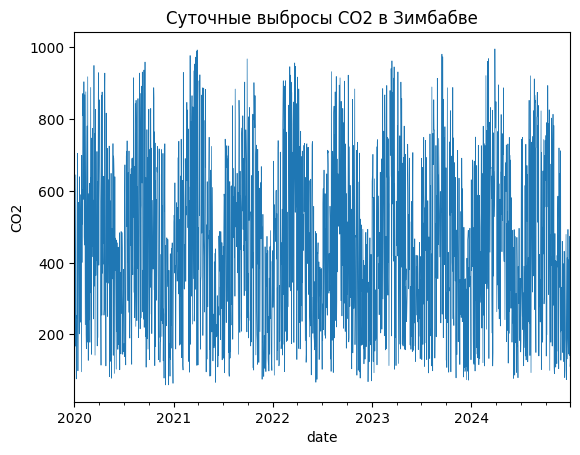

In [11]:
df['co2_emission'].plot(linewidth=0.5)
plt.title('Суточные выбросы CO2 в Зимбабве')
plt.ylabel('CO2')
plt.show()

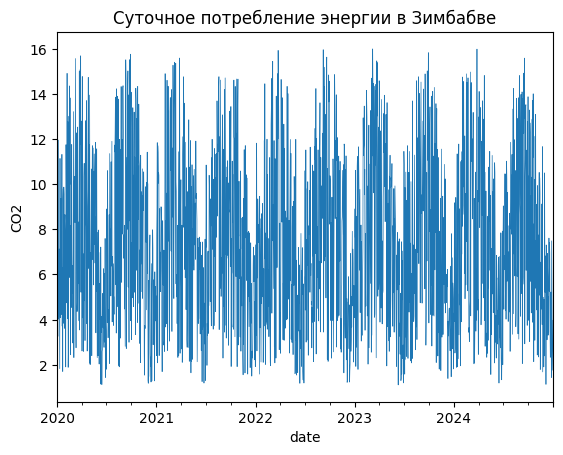

In [12]:
df['energy_consumption'].plot(linewidth=0.5)
plt.title('Суточное потребление энергии в Зимбабве')
plt.ylabel('CO2')
plt.show()

Разложим изначальный ряд на тренд, сезонность и остатки

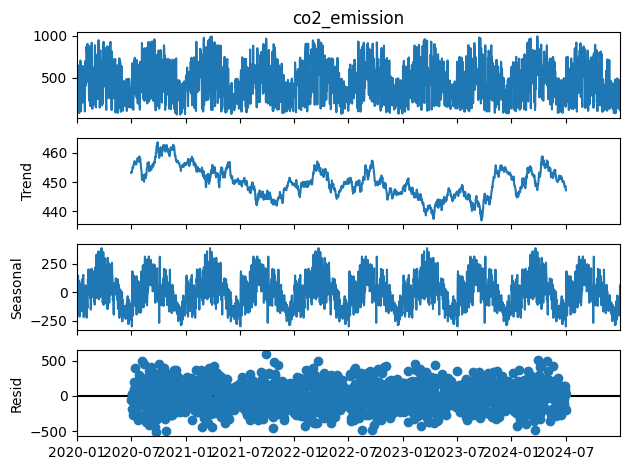

In [13]:
decomposition = seasonal_decompose(df['co2_emission'], model='additive', period = 365)
decomposition.plot()
plt.show()

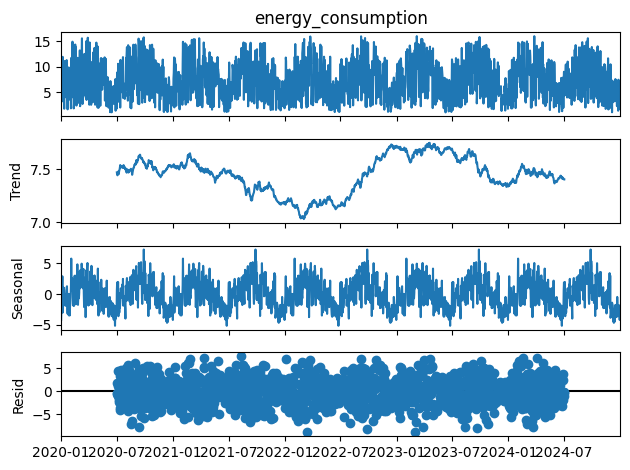

In [14]:
decomposition = seasonal_decompose(df['energy_consumption'], model='additive', period = 365)
decomposition.plot()
plt.show()

Тренд у рядов не постоянный:
*   Для энергии виден пик в 2023 году.
*   Для CO2 пик был в 2020 году

Прослеживается сезонность для обоих рядов

/tmp/ipykernel_1176/1770077918.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly_energy = df[['co2_emission']].resample('M').sum(min_count=1)
/tmp/ipykernel_1176/1770077918.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly_temp = df[['energy_consumption']].resample('M').mean()  # среднее значение температуры за месяц


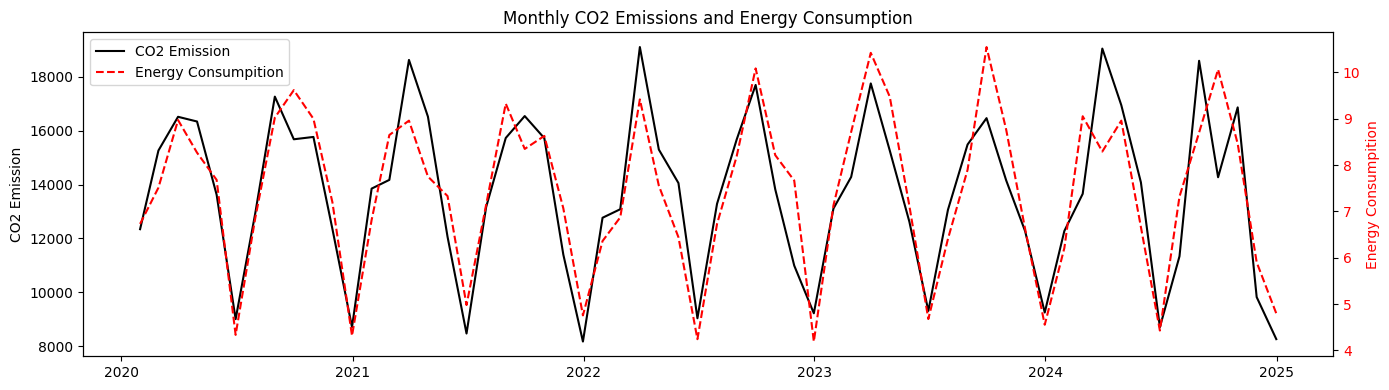

In [15]:
# Агрегация по месяцам: сумма для энергии, среднее для температуры
df_monthly_energy = df[['co2_emission']].resample('M').sum(min_count=1)
df_monthly_temp = df[['energy_consumption']].resample('M').mean()  # среднее значение температуры за месяц
df_monthly = df_monthly_energy.join(df_monthly_temp)

fig, ax1 = plt.subplots(figsize=(14, 4))

ax1.plot(df_monthly['co2_emission'], color='black', label='CO2 Emission')
ax1.set_ylabel('CO2 Emission', color='black')
ax1.tick_params(axis='y', labelcolor='black')

ax2 = ax1.twinx()
ax2.plot(df_monthly['energy_consumption'], color='red', linestyle='--', label='Energy Consumpition')
ax2.set_ylabel('Energy Consumpition', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Форматирование оси X
ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Легенда
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('Monthly CO2 Emissions and Energy Consumption')
plt.tight_layout()
plt.show()

Как видно по предыдущим графикам, в временном ряду присутствует сезонность. Построим график средних значений по месяцам, чтобы это проверить

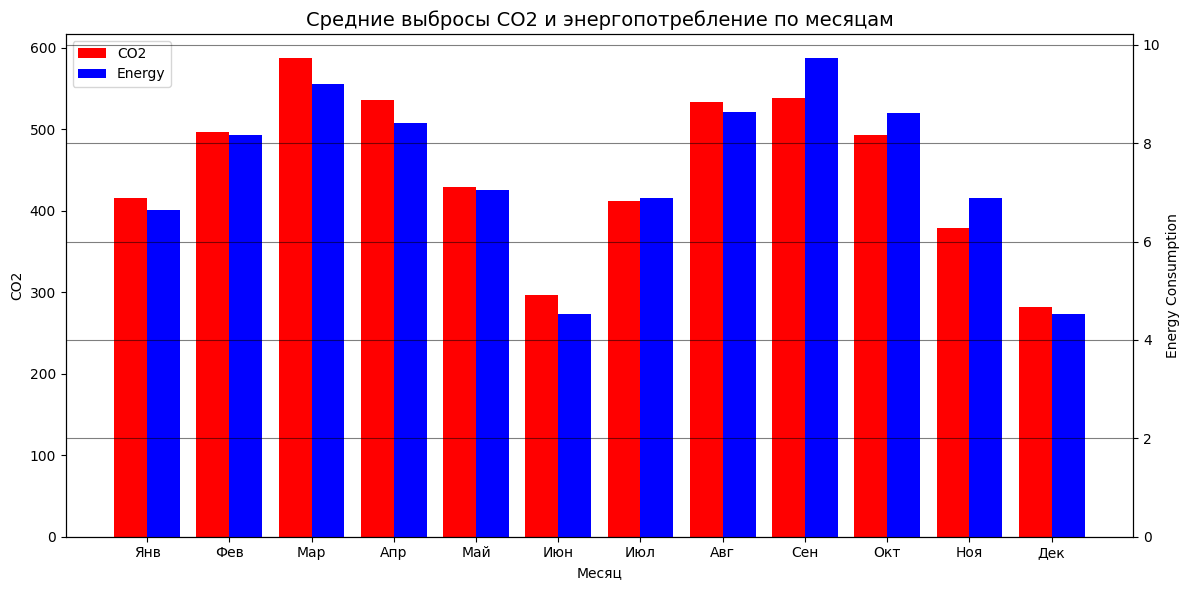

In [16]:
df['month'] = df.index.month
monthly_avg = df.groupby('month')[['co2_emission', 'energy_consumption']].mean().reset_index()

fig, ax1 = plt.subplots(figsize=(12, 6))

#CO2
ax1.set_xlabel('Месяц')
ax1.set_ylabel('CO2')
ax1.bar(monthly_avg['month'] - 0.2, monthly_avg['co2_emission'], label='CO2', width=0.4, color='red')
ax1.tick_params(axis='y')
plt.xticks(range(1, 13), ['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн', 'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек'])

#Energy Consumption
ax2 = ax1.twinx()
ax2.set_ylabel('Energy Consumption')
ax2.bar(monthly_avg['month'] + 0.2, monthly_avg['energy_consumption'],  label='Energy', width=0.4, color='blue',)
ax2.tick_params(axis='y')

plt.title('Средние выбросы CO2 и энергопотребление по месяцам', fontsize=14)
fig.tight_layout()

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.grid(alpha=0.5, color='black')
plt.show()

Проверим сезонность по дням недели

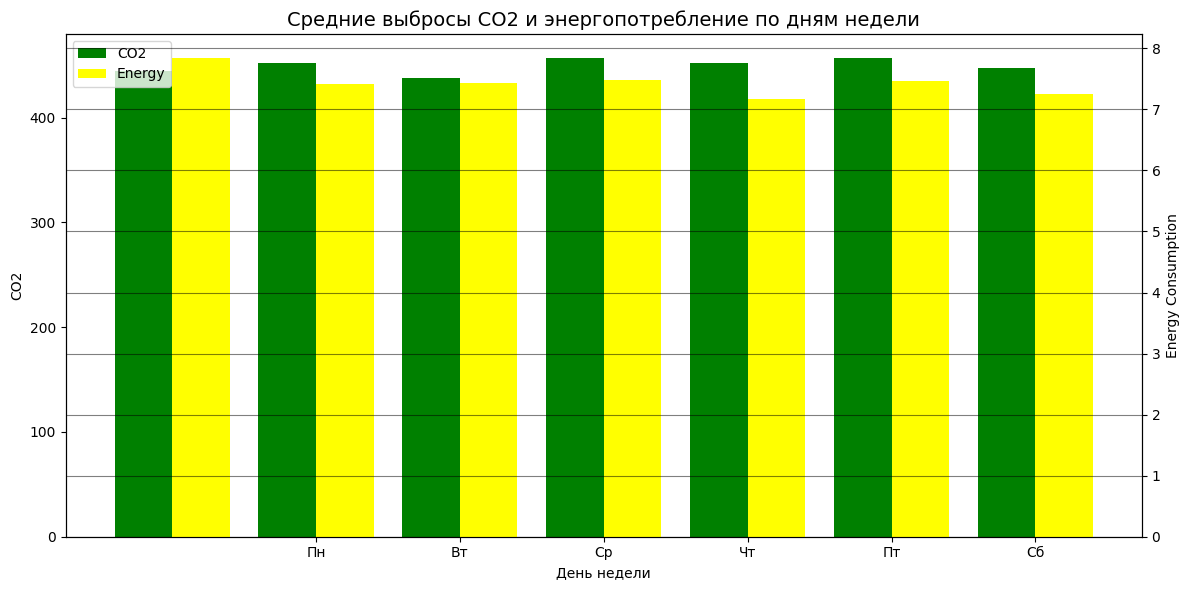

In [17]:
df['dayofweek'] = df.index.dayofweek
daily_avg = df.groupby('dayofweek')[['co2_emission', 'energy_consumption']].mean().reset_index()

fig, ax1 = plt.subplots(figsize=(12, 6))

#CO2
ax1.set_xlabel('День недели')
ax1.set_ylabel('CO2')
ax1.bar(daily_avg['dayofweek'] - 0.2, daily_avg['co2_emission'], label='CO2', width=0.4, color='green')
ax1.tick_params(axis='y')
plt.xticks(range(1, 8), ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс'])

#Energy Consumption
ax2 = ax1.twinx()
ax2.set_ylabel('Energy Consumption')
ax2.bar(daily_avg['dayofweek'] + 0.2, daily_avg['energy_consumption'],  label='Energy', width=0.4, color='yellow',)
ax2.tick_params(axis='y')

plt.title('Средние выбросы CO2 и энергопотребление по дням недели', fontsize=14)
fig.tight_layout()

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.grid(alpha=0.5, color='black')
plt.show()

Анализ полученных графиков показывает, что присутствует годовая сезонность. Пик выбросов и потребления энергии происходит с февраля по апрель и с августа по октябрь.

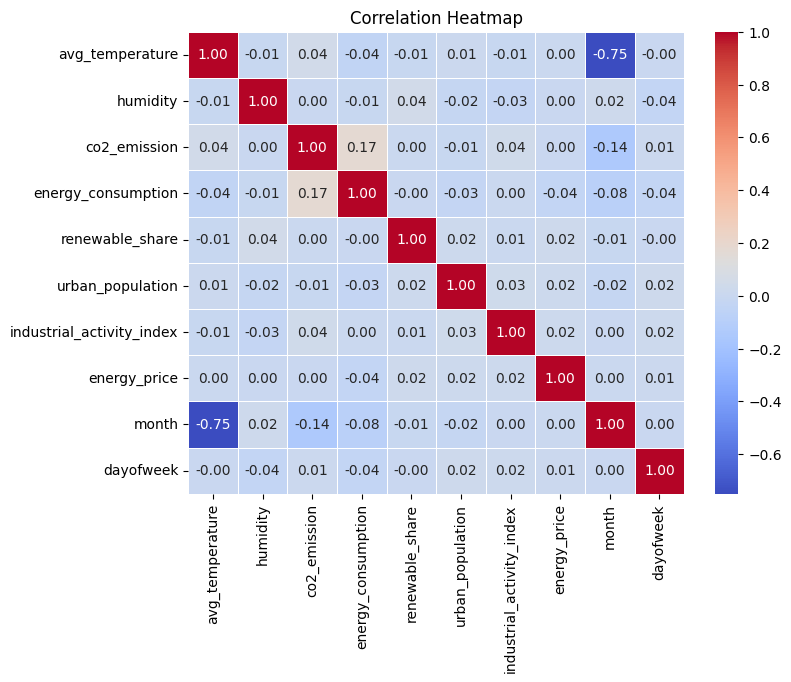

In [18]:
matrix = df.corr()
plt.figure(figsize=(8,6))
sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

#### Анализ полученных графиков показывает следующее:

- Выбросы CO2 имеют связь с потреблением энергии. Чем больше используется энергии, тем больше выбросы
- Большинство признаков не имеют сильной корреляции друг с другом


Проверим значимость экзогенных факторов с помощью теста Грейнджера на причинность

In [19]:
from statsmodels.stats.multitest import multipletests
from statsmodels.tsa.stattools import grangercausalitytests

# создадим словарь для хранения компонентов
decomposed = {}
df_ = df.copy()
system_cols = ['co2_emission', 'energy_consumption']
ex_cols = ['avg_temperature','humidity', 'urban_population', 'energy_price', 'industrial_activity_index', 'renewable_share']

# функция для многосезонного декомпозиции
def multi_seasonal_decompose(series, weekly=7, yearly=365):
    result = pd.DataFrame(index=series.index)

    # годовая сезонность на остатках после недельной
    yearly_comp = seasonal_decompose(series, period=yearly, model='additive', extrapolate_trend='freq')
    result['trend_yearly'] = yearly_comp.trend
    result['season_yearly'] = yearly_comp.seasonal
    result['resid_yearly'] = yearly_comp.resid

    return result

# применяем к системным колонкам
for col in system_cols+ex_cols:
    decomposed[col] = multi_seasonal_decompose(df_[col])
    df_[col + '_trend'] = decomposed[col]['trend_yearly']
    df_[col + '_season'] = decomposed[col]['season_yearly']
    df_[col + '_resid'] = decomposed[col]['resid_yearly']  # остатки после всех сезонностей
    df_[col + '_detrend'] = df_[col + '_season']+df_[col + '_resid']

df_resid = df_[
        [f'{c}_resid' for c in system_cols] +
        [f'{c}_resid' for c in ex_cols]].dropna()


def granger_min_pvalue(df, cause, effect, max_lag=24):
    """
    Возвращает минимальный p-value по всем лагам и позицию лага
    """
    data = df[[effect, cause]].dropna()
    results = grangercausalitytests(data, maxlag=max_lag, verbose=False)
    pvals = [results[l][0]['ssr_ftest'][1] for l in results]
    return np.min(pvals), np.argmin(pvals)

# Списки причин и следствий
causes = [f'{c}_resid' for c in ex_cols]
effects = [f'{c}_resid' for c in system_cols]

# Собираем результаты
results = []

for cause in causes:
    for effect in effects:
        res = granger_min_pvalue(df_resid, cause=cause, effect=effect, max_lag=24)
        pval, lag = res
        results.append({
            'cause': cause,
            'effect': effect,
            'pval': pval,
            'lag': lag
        })

# Создаём DataFrame
granger_df = pd.DataFrame(results)

# Вытаскиваем p-значения (игнорируя NaN)
pvals = granger_df['pval'].dropna()
original_idx = granger_df.dropna().index

# Применяем FDR-коррекцию (Benjamini-Hochberg)
_, pvals_corrected, _, _ = multipletests(pvals.values, alpha=0.05, method='fdr_bh')

# Добавляем откорректированные p-значения в DataFrame
granger_df.loc[original_idx, 'pval_corrected'] = pvals_corrected

# Фильтруем значимые результаты (после коррекции)
significant = granger_df[granger_df['pval_corrected'] < 0.05]

# Выводим результаты
if not significant.empty:
    print("Значимые Granger-причинности после FDR-коррекции (p < 0.05):")
    for _, row in significant.iterrows():
        print(f"{row['cause']} → {row['effect']} | p_corrected: {row['pval_corrected']:.3e}, lag: {row['lag']}")
else:
    print("Нет значимых Granger-причинностей после FDR-коррекции.")

Значимые Granger-причинности после FDR-коррекции (p < 0.05):
humidity_resid → co2_emission_resid | p_corrected: 4.399e-02, lag: 16
humidity_resid → energy_consumption_resid | p_corrected: 4.218e-02, lag: 22
urban_population_resid → energy_consumption_resid | p_corrected: 4.218e-02, lag: 17
energy_price_resid → energy_consumption_resid | p_corrected: 4.218e-02, lag: 12


В итоге в системе присутствует 2 целевые переменные и 3 экзогенных фактора (1 для co2_emission и 3 для energy_consumption)

Общие выводы:
*   В датасете присутствует две целевые переменные: co2_emission и energy_consumption
*   Пристутствует 3 значимых экзогенных фактора:
    * humidity для co2_emission.
    * humidity, urban_population и energy_price для energy_consumption
* Присутствует годовая сезонность для обоих целевых переменных



In [20]:
#Удалим неинформативные столбцы и сохраним обработанную таблицу
df = df.drop(columns = ['industrial_activity_index', 'renewable_share', 'avg_temperature'])
df.to_csv('climate_EDA.csv', index_label="date")